# 06 - Wybór Najliczniejszych Klas (TopN)

Ten notebook filtruje dane do 30 najczęściej występujących klas (`label`) i zapisuje wynik pod stałą nazwą `topn` do dalszego użycia.

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [20]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video.csv'
TOP_K = 50

# Stale nazwy wyjscia (bez parametryzacji w nazwie pliku).
OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_classes.csv'
OUTPUT_LABELS_CSV = PROJECT_ROOT / 'merged_datasets' / 'topn_labels.csv'

print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('OUTPUT_LABELS_CSV:', OUTPUT_LABELS_CSV)
print('TOP_K:', TOP_K)

INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_has_video.csv
OUTPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_LABELS_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\topn_labels.csv
TOP_K: 50


In [21]:
df = pd.read_csv(INPUT_CSV)

print('Shape (oryginal):', df.shape)
print('Liczba klas (oryginal):', df['label'].nunique())

display(df.head())

Shape (oryginal): (11980, 12)
Liczba klas (oryginal): 2000


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,book,aslbrick,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,75.0,75.0,2.502,29.970030,118,True,1280.0,720.0
1,book,signschool,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,30.0,30.0,1.251,23.976024,31,True,1280.0,720.0
2,book,startasl,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,68.0,68.0,2.269,29.970000,36,True,736.0,414.0
3,book,asldeafined,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,86.0,86.0,2.866,30.003489,59,True,640.0,480.0
4,book,aslsearch,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,87.0,87.0,2.870,30.318841,12,True,720.0,400.0


In [22]:
label_counts = df['label'].value_counts()
topn_labels = label_counts.head(TOP_K).index.tolist()

topn_df = df[df['label'].isin(topn_labels)].copy()
topn_counts = topn_df['label'].value_counts()

print('Liczba klas po filtracji:', topn_df['label'].nunique())
print('Shape (po filtracji):', topn_df.shape)

display(topn_counts.to_frame('count').head(TOP_K))

Liczba klas po filtracji: 50
Shape (po filtracji): (614, 12)


,count
label,
before,16
thin,16
cool,16
drink,15
go,15
computer,14
who,14
cousin,14
help,14


In [23]:
topn_df.to_csv(OUTPUT_CSV, index=False)
pd.DataFrame({'label': topn_labels}).to_csv(OUTPUT_LABELS_CSV, index=False)

print('Zapisano pliki:')
print('-', OUTPUT_CSV)
print('-', OUTPUT_LABELS_CSV)

Zapisano pliki:
- C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
- C:\Users\kacpe\source\repos\szum\merged_datasets\topn_labels.csv


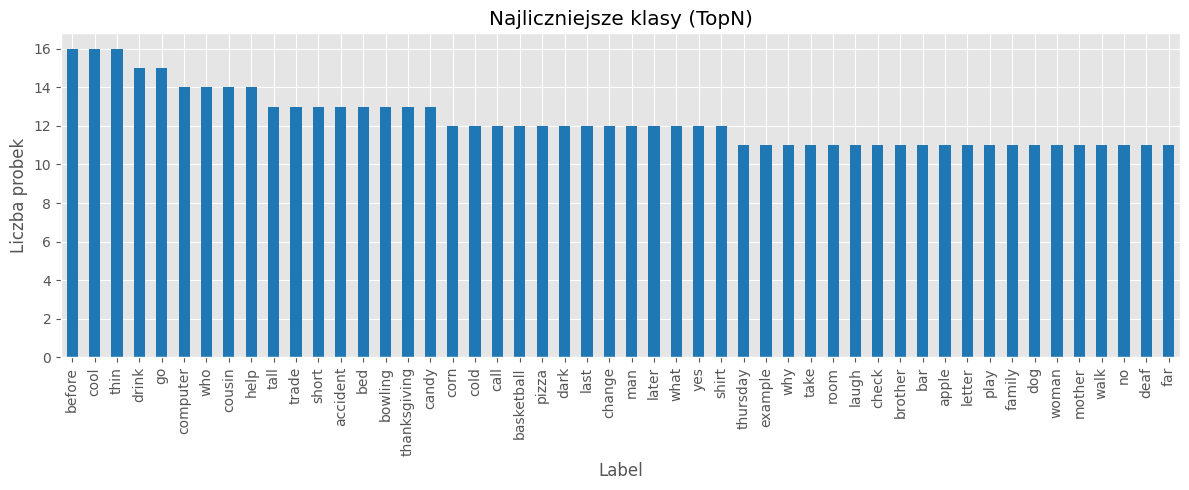

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
topn_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Najliczniejsze klasy (TopN)')
ax.set_xlabel('Label')
ax.set_ylabel('Liczba probek')
plt.tight_layout()
plt.show()